In [3]:
import pandas as pd

df = pd.read_csv('cleaned_movies.csv')

df.head(5)

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,status,tagline,title,vote_average,vote_count,cast,crew,director,year,profit
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2009.0,2550965087
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski,2007.0,661000000
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes,2015.0,635674609
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan,2012.0,834939099
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton,2012.0,24139100


In [4]:
df['ROI'] = (df['revenue'] - df['budget']) / df['budget']

genre_dummies = df['genres'].fillna('').str.get_dummies(sep=' ')

df = pd.concat([df, genre_dummies], axis=1)

df[['title', 'budget', 'revenue', 'Action', 'Comedy', 'Drama', 'ROI']].head()

,title,budget,revenue,Action,Comedy,Drama,ROI
0,Avatar,237000000,2787965087,1,0,0,10.763566
1,Pirates of the Caribbean: At World's End,300000000,961000000,1,0,0,2.203333
2,Spectre,245000000,880674609,1,0,0,2.594590
3,The Dark Knight Rises,250000000,1084939099,1,0,1,3.339756
4,John Carter,260000000,284139100,1,0,0,0.092843


In [5]:
from sklearn.model_selection import train_test_split

feature_columns = ['budget', 'year', 'Action', 'Comedy', 'Drama', 'Thriller']
X = df[feature_columns].fillna(0)

y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} movies")
print(f"Testing data size: {X_test.shape[0]} movies")

Training data size: 2911 movies
Testing data size: 728 movies


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"R-squared Score: {r2:.3f}")
print(f"Average Error: ${mae:,.2f}")



R-squared Score: 0.514
Average Error: $78,330,594.02


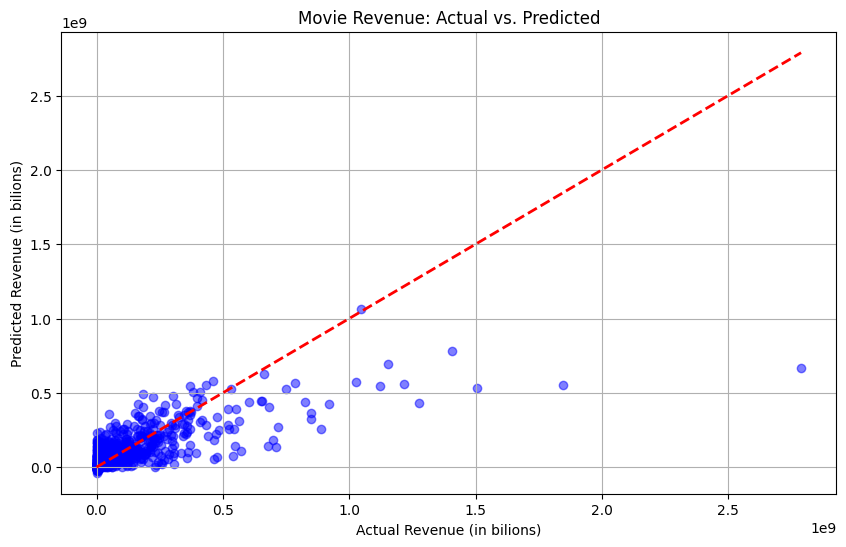

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(y_test, predictions, alpha=0.5, color='blue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)

plt.title("Movie Revenue: Actual vs. Predicted")
plt.xlabel("Actual Revenue (in bilions)")
plt.ylabel("Predicted Revenue (in bilions)")
plt.grid(True)
plt.show()